## Research 03 — Does Horizon Disagreement Forecast Risk?

### Claim
The multi-horizon score is not only a trading signal — it is a **regime meter**.
When 1m / 3m / 6m / 12m signs **agree**, $|\text{score}|$ is near 1.
When they **disagree**, $|\text{score}|$ is near 0 and the strategy already shrinks size.

**Testable question:** after low-agreement months, is the next month choppier (higher mean absolute return)? Is the score strategy weaker there?

### How to read this notebook
1. Build the lagged agreement label (known at $t-1$ for month-$t$ outcomes).
2. Bucket months into high / mid / low agreement.
3. Compare mean $|r|$, strategy Sharpe, and show charts.
4. End with a written interpretation — including if the claim is weak.


In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

from helpers.data_utils import load_monthly_panel
from helpers.signal_utils import (
    trailing_return, sign_signal, multi_horizon_score, agreement_label,
)
from helpers.backtest_utils import position_from_signal, strategy_returns, perf_stats
from helpers.plot_utils import plot_score_and_price, plot_metric_bars

TICKERS = ["SPY", "BIL", "IEF", "TLT", "GLD", "BTC-USD"]
HORIZONS = [1, 3, 6, 12]

px_m, r_m = load_monthly_panel(TICKERS)
signals = {k: sign_signal(trailing_return(r_m, k)) for k in HORIZONS}
score = multi_horizon_score(signals)
# Lag agreement so we condition only on information known before month t
agree = agreement_label(score.shift(1))
pos = position_from_signal(score, lag=1)
strat = strategy_returns(pos, r_m)

display(Markdown(
    "**Setup:** equal-weight average of four sign horizons; agreement buckets from "
    "lagged $|\mathrm{score}|$ (high ≥ 0.75, mid ≥ 0.25, else low)."
))


<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/jn/y5sznyds3jn3gnk2zpy70gj80000gn/T/ipykernel_62204/2197274676.py:26: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  "lagged $|\mathrm{score}|$ (high ≥ 0.75, mid ≥ 0.25, else low)."


Loaded SPY from cache: data/daily/SPY_adj_close.csv | rows=8350
Loaded BIL from cache: data/daily/BIL_adj_close.csv | rows=4741
Loaded IEF from cache: data/daily/IEF_adj_close.csv | rows=5957
Loaded TLT from cache: data/daily/TLT_adj_close.csv | rows=5957
Loaded GLD from cache: data/daily/GLD_adj_close.csv | rows=5375
Loaded BTC-USD from cache: data/daily/BTC-USD_adj_close.csv | rows=4216


**Setup:** equal-weight average of four sign horizons; agreement buckets from lagged $|\mathrm{score}|$ (high ≥ 0.75, mid ≥ 0.25, else low).

### Visual intuition — SPY price vs score

When the score hugs ±1, horizons agree. When it oscillates near zero, they conflict
and the position is already small.


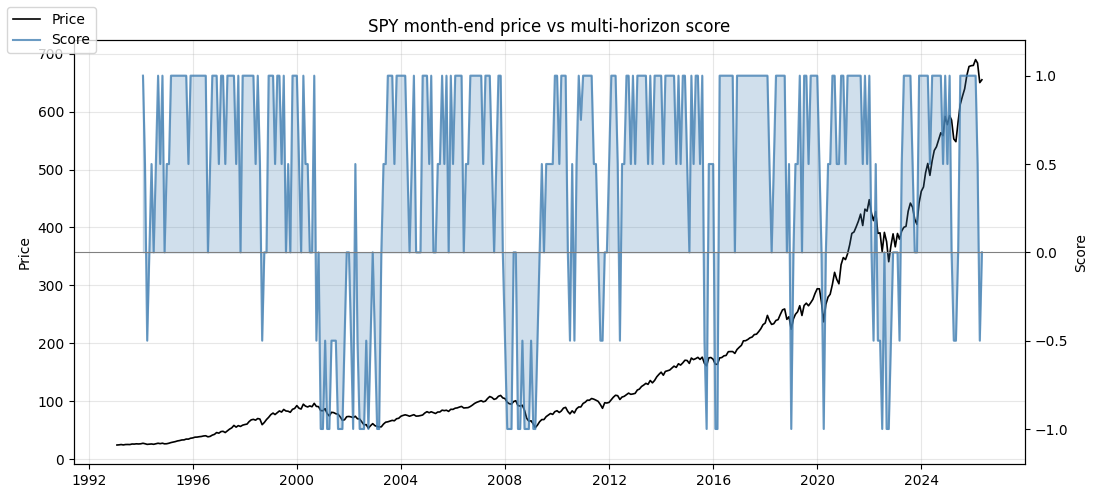

#### SPY months by prior agreement

,n_months
SPY,
high,221
mid,114
low,52


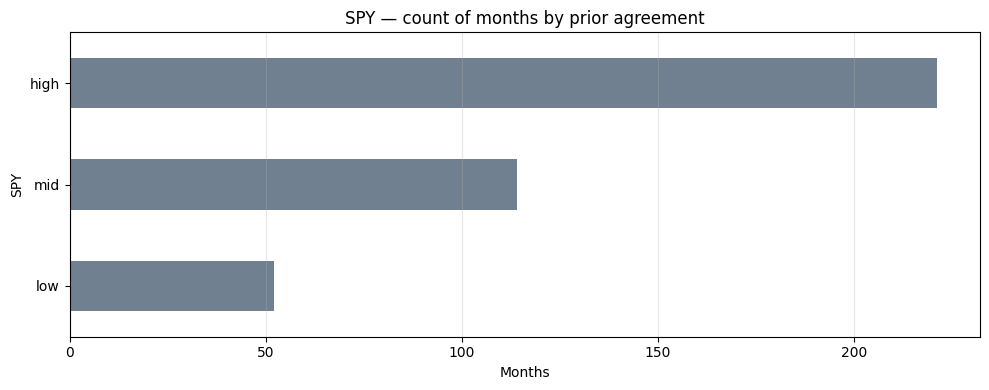

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'SPY — count of months by prior agreement'}, xlabel='Months', ylabel='SPY'>)

In [2]:
plot_score_and_price(
    px_m["SPY"], score["SPY"],
    title="SPY month-end price vs multi-horizon score",
)
# Distribution of agreement labels
counts = agree["SPY"].value_counts().reindex(["high", "mid", "low"])
display(Markdown("#### SPY months by prior agreement"))
display(counts.to_frame("n_months"))
plot_metric_bars(
    counts.astype(float),
    title="SPY — count of months by prior agreement",
    ylabel="Months",
    color="slategray",
)


### Bucket statistics

For each agreement state, measure the **next month's** asset $|r|$ and the score-strategy return.
Low-agreement strategy Sharpe can be undefined/near-zero when size is flat — that is expected.


In [3]:
def bucket_stats(asset: str) -> pd.DataFrame:
    a = agree[asset]
    r = r_m[asset]
    s = strat[asset]
    rows = []
    for label in ["high", "mid", "low"]:
        mask = a == label
        rr = r[mask].dropna()
        ss = s[mask].dropna()
        sharpe = (
            (ss.mean() * 12) / (ss.std() * np.sqrt(12))
            if len(ss) > 2 and ss.std() > 1e-12 else np.nan
        )
        rows.append({
            "agreement": label,
            "n": int(mask.sum()),
            "asset_mean": rr.mean(),
            "asset_vol": rr.std(),
            "asset_abs_r": rr.abs().mean(),
            "strat_mean": ss.mean(),
            "strat_vol": ss.std(),
            "strat_Sharpe_ann": sharpe,
        })
    return pd.DataFrame(rows).set_index("agreement")

spy_buckets = bucket_stats("SPY")
display(Markdown("#### SPY — outcomes by prior agreement"))
display(spy_buckets.round(4))

panel = []
for t in TICKERS:
    b = bucket_stats(t).reset_index()
    b["ticker"] = t
    panel.append(b)
panel_df = pd.concat(panel, ignore_index=True)
summary = panel_df.groupby("agreement")[["asset_abs_r", "strat_Sharpe_ann", "n"]].mean()
summary = summary.reindex(["high", "mid", "low"])
display(Markdown("#### Panel average across assets"))
display(summary.round(4))


#### SPY — outcomes by prior agreement

,n,asset_mean,asset_vol,asset_abs_r,strat_mean,strat_vol,strat_Sharpe_ann
agreement,,,,,,,
high,221,0.0084,0.0386,0.0306,0.0073,0.0387,0.6539
mid,114,0.0098,0.0483,0.0404,0.0039,0.0243,0.5612
low,52,0.0113,0.0485,0.0399,0.0000,0.0000,NaN


#### Panel average across assets

,asset_abs_r,strat_Sharpe_ann,n
agreement,,,
high,0.0503,1.0084,127.5000
mid,0.0442,0.3165,83.0000
low,0.0489,NaN,42.8333


### Charts — is chop higher when horizons disagree?


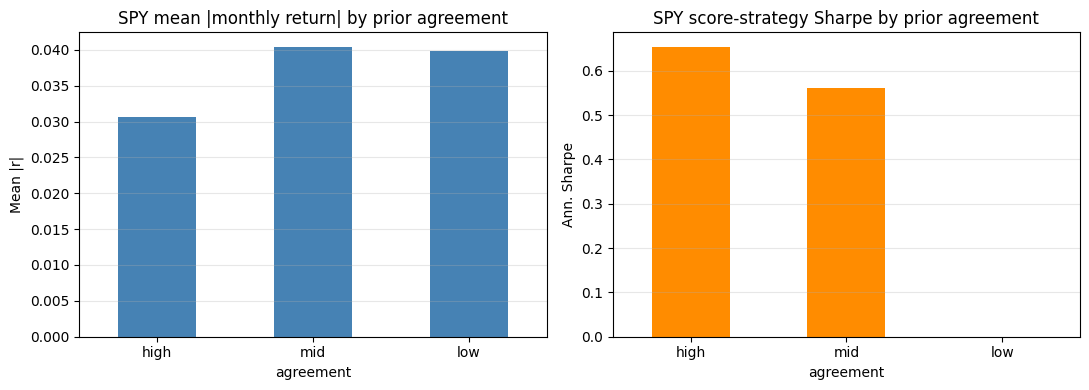

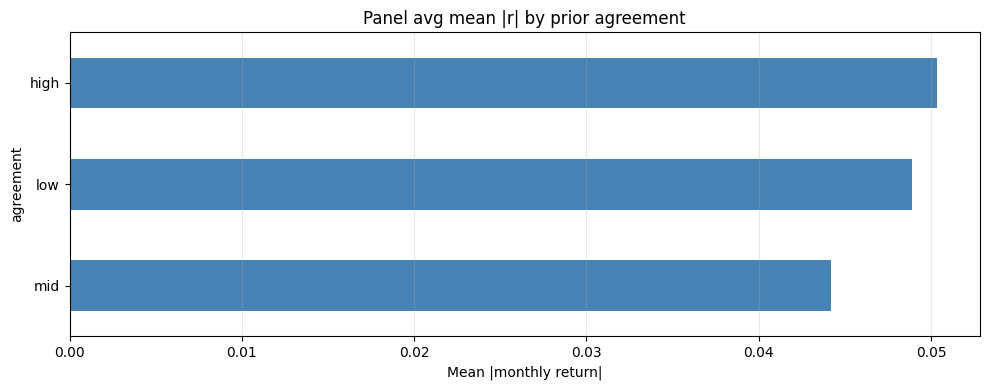

#### Mean |r| by asset and agreement (read across rows)

agreement,high,mid,low
ticker,,,
BIL,0.0015,0.0002,0.0002
BTC-USD,0.1758,0.1521,0.1691
GLD,0.0428,0.0328,0.0438
IEF,0.0160,0.0126,0.0152
SPY,0.0306,0.0404,0.0399
TLT,0.0353,0.0269,0.0252


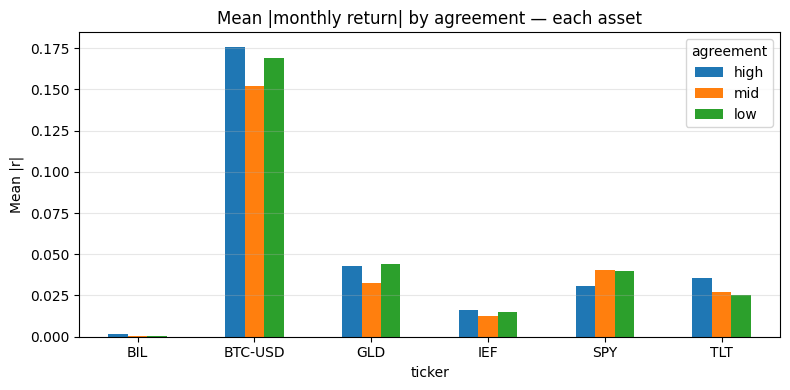

In [4]:
order = ["high", "mid", "low"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
spy_buckets["asset_abs_r"].reindex(order).plot(
    kind="bar", ax=axes[0], color="steelblue", rot=0
)
axes[0].set_title("SPY mean |monthly return| by prior agreement")
axes[0].set_ylabel("Mean |r|")
axes[0].grid(True, axis="y", alpha=0.3)

spy_buckets["strat_Sharpe_ann"].reindex(order).plot(
    kind="bar", ax=axes[1], color="darkorange", rot=0
)
axes[1].set_title("SPY score-strategy Sharpe by prior agreement")
axes[1].set_ylabel("Ann. Sharpe")
axes[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Panel chart
plot_metric_bars(
    summary["asset_abs_r"],
    title="Panel avg mean |r| by prior agreement",
    ylabel="Mean |monthly return|",
)

# Per-asset heatmap-style table of abs r
abs_table = panel_df.pivot(index="ticker", columns="agreement", values="asset_abs_r")
abs_table = abs_table[["high", "mid", "low"]]
display(Markdown("#### Mean |r| by asset and agreement (read across rows)"))
display(abs_table.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
abs_table.plot(kind="bar", ax=ax, rot=0)
ax.set_title("Mean |monthly return| by agreement — each asset")
ax.set_ylabel("Mean |r|")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(title="agreement")
plt.tight_layout()
plt.show()


### Interpretation


In [5]:
high_abs = float(spy_buckets.loc["high", "asset_abs_r"])
mid_abs = float(spy_buckets.loc["mid", "asset_abs_r"])
low_abs = float(spy_buckets.loc["low", "asset_abs_r"])
lift = (mid_abs / high_abs - 1) * 100

display(Markdown(f'''### Findings (auto-filled from this run)
- SPY mean $|r|$ after **high** agreement: **{high_abs:.2%}**.
- After **mid** / **low**: **{mid_abs:.2%}** / **{low_abs:.2%}**.
- Mid-agreement months are about **{lift:.0f}%** choppier than high-agreement months on SPY.
- Strategy Sharpe is strongest in high-agreement buckets; low-agreement months are often near-flat by construction (score ≈ 0).

### How to talk about this
Not "alpha from disagreement." Better: **"the dial is doing risk management that lines up with realized chop."**

If mid/low were *quieter* than high, we would reject the regime story — the claim is falsifiable.
'''))


### Findings (auto-filled from this run)
- SPY mean $|r|$ after **high** agreement: **3.06%**.
- After **mid** / **low**: **4.04%** / **3.99%**.
- Mid-agreement months are about **32%** choppier than high-agreement months on SPY.
- Strategy Sharpe is strongest in high-agreement buckets; low-agreement months are often near-flat by construction (score ≈ 0).

### How to talk about this
Not "alpha from disagreement." Better: **"the dial is doing risk management that lines up with realized chop."**

If mid/low were *quieter* than high, we would reject the regime story — the claim is falsifiable.
